# Test 2 (Rigol DG4162) — Adquisición con OR_MASK (multitrigger)

Igual que `multitrigger_test_adq_dac.ipynb` pero la señal proviene de un
**generador externo Rigol DG4162** en lugar del DAC interno.

**Conexión física:** Rigol **CH1 → IN1**, Rigol **CH2 → IN2**. Trenes de
pulsos 0→1 V a 100 kHz (CH1) y 25 kHz (CH2).

Flujo:
1. Rigol: pulsos 100 kHz en CH1→IN1 y 25 kHz en CH2→IN2.
2. Acquisition: decimación, threshold y delay (API `rp` en las celdas inline;
   escritura directa en el test de `capture_window_np`).
3. **OR_MASK** = `0xFFFF_FFFF` en `0x240`/`0x244` — vía `/dev/mem`.
4. Arm + trigger + lectura del buffer + debug regs.
5. Validación de timing por canal y captura con `capture_window_np`.

In [60]:
import time, mmap, os, struct
import numpy as np
from matplotlib import pyplot as plt
import rp

# === Cómo cargar un bitstream propio vía rp_overlay ===
# Hay que dejar en /opt/redpitaya/fpga/<nombre_proyecto>/ los archivos:
#   - fpga.bit.bin   (bitstream en formato Zynq con header)
#   - fpga.dtbo      (device tree overlay)
#
# Setup típico desde la Pitaya:
#   redpitaya> mkdir -p /opt/redpitaya/fpga/$(monitor -f)/MCA
#   redpitaya> cp /root/red_pitaya_top.bit.bin \
#                 /opt/redpitaya/fpga/$(monitor -f)/MCA/fpga.bit.bin
#   redpitaya> cp /root/devicetree.dtbo \
#                 /opt/redpitaya/fpga/$(monitor -f)/MCA/fpga.dtbo
#
# Luego desde Python:
#   from rp_overlay import overlay
#   fpga = overlay("MCA")          # ← NOMBRE del directorio, NO el .bit.bin
#
# Mientras desarrollás podés bypasear el overlay con fpgautil (solo carga
# el bitstream, NO el device tree — sirve para acceso /dev/mem directo):
#   !fpgautil -b /root/red_pitaya_top.bit.bin

rp.rp_Init()

# /dev/mem helper para la zona multitrigger (0x210, 0x214, 0x218, 0x21C, 0x240+)
SCOPE_PHYS = 0x4010_0000
SCOPE_SIZE = 0x30000
fd = os.open('/dev/mem', os.O_RDWR | os.O_SYNC)
scope = mmap.mmap(fd, SCOPE_SIZE, mmap.MAP_SHARED,
                  mmap.PROT_READ | mmap.PROT_WRITE, offset=SCOPE_PHYS)

def w32(off, v):
    scope[off:off+4] = struct.pack('<I', v & 0xFFFFFFFF)

def r32(off):
    return struct.unpack('<I', scope[off:off+4])[0]

OR_MASK_ALL = 0xFFFF_FFFF  # vector de 1: todas las fuentes habilitadas
N_BUF = 16384
FS    = 125e6              # Hz, sampling rate con decimación 1

In [61]:
# Comprobación de carga del bitstream
!fpgautil -b /root/red_pitaya_top.bit.bin
# Tenemos que hacer fpgautil -b top.bit.bin 

print(f'0x14  set_dec_ch0  = {r32(0x14):#010x}  (esperado tras reset: 0x00000001)')
print(f'0x114 set_dec_ch1  = {r32(0x114):#010x}  (esperado tras reset: 0x00000001)')
print(f'0x204 calib_gain_0 = {r32(0x204):#010x}  (esperado tras reset: 0x00008000)')
print(f'0x21C we_keep+dis  = {r32(0x21C):#010x}  (esperado tras reset: 0)')
print(f'0x240 trg_src_ch0  = {r32(0x240):#010x}')

Time taken to load BIN is 39.000000 Milli Seconds
BIN FILE loaded through FPGA manager successfully
0x14  set_dec_ch0  = 0x00000001  (esperado tras reset: 0x00000001)
0x114 set_dec_ch1  = 0x00000001  (esperado tras reset: 0x00000001)
0x204 calib_gain_0 = 0x00008000  (esperado tras reset: 0x00008000)
0x21C we_keep+dis  = 0x00000000  (esperado tras reset: 0)
0x240 trg_src_ch0  = 0x00000000


## Rigol DG4162: pulsos CH1→IN1 (100 kHz), CH2→IN2 (25 kHz)

In [65]:
# Generador EXTERNO Rigol DG4162. CH1 -> IN1, CH2 -> IN2.
# Dos trenes de pulsos a freqs distintas (mirror del DAC 100/25 kHz) para
# validar el OR_MASK por canal.
from rigol_dg4162 import RigolDG4162

rg = RigolDG4162.vxi11('10.73.28.27')    # o: RigolDG4162.tcp('192.168.1.10') / .vxi11(host)
print('Rigol:', rg.id)
rg.reset()

def configure_rigol(f_ch1=100_000, f_ch2=25_000, width_s=2e-6,
                    amp_vpp=1.0, offset_v=0.5, chs=(1, 2)):
    """Trenes de pulsos 0->1 V. chs = canales del Rigol a encender (1 y/o 2).
    Los canales no listados quedan apagados."""
    freqs = {1: f_ch1, 2: f_ch2}
    for ch in (1, 2):
        if ch in chs:
            rg.set_pulse_periodic(ch=ch, period_s=1.0 / freqs[ch], width_s=width_s,
                                  amp_vpp=amp_vpp, offset_v=offset_v)
            rg.output(ch, True)
        else:
            rg.output(ch, False)
    time.sleep(0.1)

configure_rigol()
print('Rigol: CH1=100kHz -> IN1, CH2=25kHz -> IN2 (pulsos 0->1 V)')

Exception ignored in: <function Device.__del__ at 0xaa218220>
Traceback (most recent call last):
  File "/usr/local/lib/python3.10/dist-packages/vxi11/vxi11.py", line 560, in __del__
    self.close()
  File "/usr/local/lib/python3.10/dist-packages/vxi11/vxi11.py", line 613, in close
    self.client.destroy_link(self.link)
  File "/usr/local/lib/python3.10/dist-packages/vxi11/vxi11.py", line 473, in destroy_link
    return self.make_call(DESTROY_LINK, link,
  File "/usr/local/lib/python3.10/dist-packages/vxi11/rpc.py", line 178, in make_call
    self.do_call()
  File "/usr/local/lib/python3.10/dist-packages/vxi11/rpc.py", line 270, in do_call
    reply = recvrecord(self.sock)
  File "/usr/local/lib/python3.10/dist-packages/vxi11/rpc.py", line 247, in recvrecord
    last, frag = recvfrag(sock)
  File "/usr/local/lib/python3.10/dist-packages/vxi11/rpc.py", line 229, in recvfrag
    header = sock.recv(4)
TimeoutError: timed out


Rigol: Rigol Technologies,DG4162,DG4C152200416,00.01.05
Rigol: CH1=100kHz -> IN1, CH2=25kHz -> IN2 (pulsos 0->1 V)


In [ ]:
# --- Reconexion del Rigol (correr SOLO si un comando tira TimeoutError) ---
# Un link VXI-11 puede quedar trabado si se interrumpe una celda con el Rigol
# a mitad de un comando (red OK + portmap OK pero el write se cuelga). Esta
# celda cierra y reabre el link, y opcionalmente hace un device clear.

def rigol_reconnect(host='10.73.28.35', clear=True):
    """Reabre el link VXI-11 al Rigol si quedo trabado. Actualiza el global rg."""
    global rg
    try:
        rg.close()
    except Exception:
        pass
    rg = RigolDG4162.vxi11(host)
    if clear:
        try:
            rg._t.instr.clear()          # VXI-11 device clear: destraba un DG4000 colgado
        except Exception as e:
            print('device clear no disponible:', e)
    print('Rigol reconectado:', rg.id)   # si imprime el IDN, el link se recupero
    return rg

# Descomentar y correr esta celda cuando haga falta reconectar:
# rigol_reconnect()

## ACQ base + OR_MASK + captura

In [66]:
# Helpers del scope: usamos directamente la clase MultiTriggerScope de
# multitrigger_utils en vez de redefinir todo inline.
from multitrigger_utils import MultiTriggerScope, decode_snap

# Reusa el mmap/fd ya abiertos en la celda de imports (no re-mapea /dev/mem;
# por eso NO se llama sc.close(): el cierre lo hace la celda de cleanup).
sc = MultiTriggerScope(scope, fd)

# Aliases para que las celdas de abajo llamen a los métodos de la clase con
# los nombres de siempre.
acq_base        = sc.acq_base          # config por ESCRITURA DIRECTA (decim/thr/delay)
set_or_mask     = sc.set_or_mask       # set_or_mask(mask) o set_or_mask(m0, m1)
wait_triggered  = sc.wait_triggered
wait_fill       = sc.wait_fill
read_buffers    = sc.read_buffers
debug_dump      = sc.debug_dump
debug_trigger   = sc.debug_trigger
decode_snapshot = decode_snap          # mismo decoder del snapshot @0x218

print('MultiTriggerScope listo: acq_base/set_or_mask/wait_*/read_buffers/debug_* via sc')

MultiTriggerScope listo: acq_base/set_or_mask/wait_*/read_buffers/debug_* via sc


In [67]:
# --- Guardado de datos crudos para analisis offline ---
# Cada captura se guarda en datos/ como .npz: arrays (d1, d2, ...) + metadata
# con un snapshot de los registros del scope en ese momento. Asi se puede
# reanalizar la altura/periodicidad de los pulsos sin volver a correr el HW.
#
# Layout (esquema plano con prefijo por corrida):
#   datos/<AAAAMMDD_HHMMSS>__<label>.npz
#   ej: datos/20260804_153012__casoB_in2_25k.npz
# El <stamp> es unico por ejecucion del notebook (todas las capturas de una
# corrida comparten prefijo), y <label> lo pasa cada celda.
#
# Cargar despues (offline):
#   npz = np.load('datos/<archivo>.npz', allow_pickle=True)
#   d1, d2 = npz['d1'], npz['d2']
#   regs   = npz['meta'].item()        # dict con snapshot, mask, wp_trig, ...

DATA_DIR   = 'datos'
_RUN_STAMP = time.strftime('%Y%m%d_%H%M%S')   # un stamp por corrida del notebook
os.makedirs(DATA_DIR, exist_ok=True)

def scope_regs(sc):
    """Snapshot de los registros clave del scope (para la meta de cada captura)."""
    return dict(
        adc_state=sc.r32(0x00),  trg_state=sc.r32(0x04),
        thr_ch0=sc.r32(0x08),    thr_ch1=sc.r32(0x0C),
        dly_ch0=sc.r32(0x10),    dly_ch1=sc.r32(0x110),
        dec_ch0=sc.r32(0x14),    dec_ch1=sc.r32(0x114),
        hyst_ch0=sc.r32(0x20),   hyst_ch1=sc.r32(0x24),
        shield=sc.r32(0x210),    shield_rt=sc.r32(0x214),
        snapshot=sc.r32(0x218),  dis_we=sc.r32(0x21C),
        mask_ch0=sc.r32(0x240),  mask_ch1=sc.r32(0x244),
        wp_trig0=sc.r32(0x1C),   wp_trig1=sc.r32(0x11C),
        wp_cur0=sc.r32(0x18),    wp_cur1=sc.r32(0x118),
    )

def save_capture(label, meta=None, **arrays):
    """Guarda una captura en datos/<stamp>__<label>.npz para analisis offline.

    label : nombre de la etapa (ej. 'first_capture', 'casoB_25k').
    arrays: nombre=ndarray, ej. save_capture('x', d1=d1, d2=d2).
    meta  : dict de escalares/registros (usar meta=scope_regs(sc), + extras).
    Devuelve el path escrito.
    """
    os.makedirs(DATA_DIR, exist_ok=True)
    path = os.path.join(DATA_DIR, f'{_RUN_STAMP}__{label}.npz')
    payload = {k: np.asarray(v) for k, v in arrays.items()}
    payload['label']  = label
    payload['fs']     = FS
    payload['t_wall'] = time.time()
    if meta:
        payload['meta'] = np.array(meta, dtype=object)   # dict -> array 0-d (item())
    np.savez_compressed(path, **payload)
    shapes = ', '.join(f'{k}{np.asarray(v).shape}' for k, v in arrays.items())
    print(f'  [save] {path}  <- {shapes}')
    return path

print(f'guardado listo -> {DATA_DIR}/  (stamp {_RUN_STAMP})')

guardado listo -> datos/  (stamp 20260527_215917)


  [save] datos/20260527_215917__sanity_in1.npz  <- d1(16384,), d2(16384,)
IN1:
  FFT pico      =    99182.1 Hz
  cruces 0 asc  =    99993.3 Hz   (debería matchear FFT)
  pico-pico     = 1.004 V
  media         = +0.185 V
  snapshot @0x218 = 0x00000000  (debería tener el SW bit o el flanco que disparó)


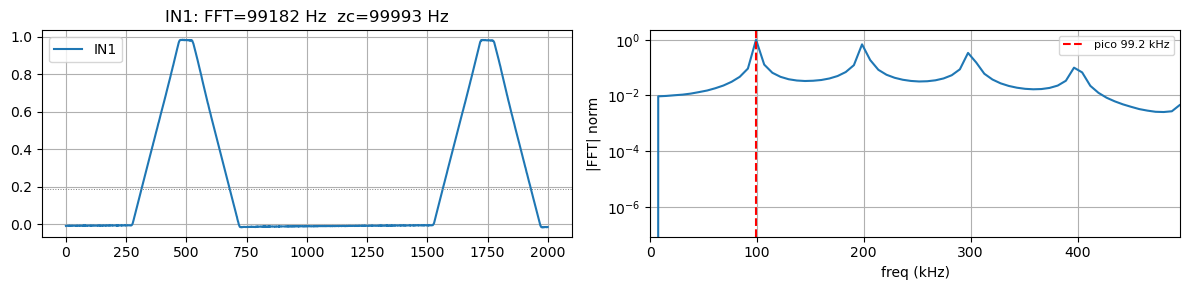

  [save] datos/20260527_215917__sanity_in2.npz  <- d1(16384,), d2(16384,)
IN2:
  FFT pico      =    76293.9 Hz
  cruces 0 asc  =    25000.0 Hz   (debería matchear FFT)
  pico-pico     = 1.006 V
  media         = +0.042 V
  snapshot @0x218 = 0x00000000  (debería tener el SW bit o el flanco que disparó)


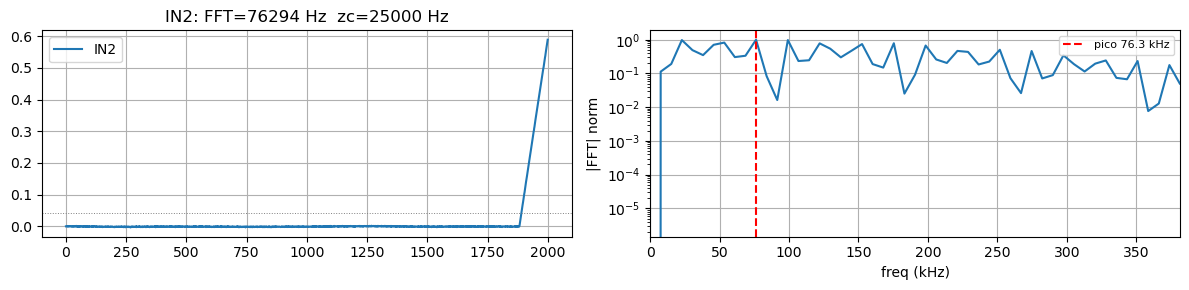

(array([-0.00036621, -0.00036621, -0.00012207, ..., -0.00048828,
        -0.00134277, -0.00061035]),
 76293.94531249999)

In [72]:
# === Sanity check del ADC con SEÑAL EXTERNA o DAC ===
# acq_capture_sw viene de la clase (fuerza UN trigger SW, espera fill y lee el
# buffer congelado). adc_signal_check es análisis local del notebook.
acq_capture_sw = sc.acq_capture_sw

def adc_signal_check(channel=1, plot_n=2000):
    """Captura UNA ventana consistente (SW trigger) y muestra forma + FFT."""
    d1, d2, snap = acq_capture_sw()
    # guardar crudo de AMBOS canales (analisis offline de altura/periodicidad)
    save_capture(f'sanity_in{channel}', d1=d1, d2=d2,
                 meta={**scope_regs(sc), 'snapshot': snap})
    d = d1 if channel == 1 else d2

    sig   = d - d.mean()
    fft   = np.abs(np.fft.rfft(sig))
    freqs = np.fft.rfftfreq(N_BUF, d=1/FS)
    f_fft = freqs[np.argmax(fft[1:]) + 1]

    sign = np.sign(d - d.mean())
    idx  = np.where(np.diff(sign) > 0)[0]
    f_zc = (1e6 / (np.diff(idx).mean() / FS * 1e6)) if len(idx) >= 2 else float('nan')

    print(f'IN{channel}:')
    print(f'  FFT pico      = {f_fft:>10.1f} Hz')
    print(f'  cruces 0 asc  = {f_zc:>10.1f} Hz   (debería matchear FFT)')
    print(f'  pico-pico     = {d.max()-d.min():.3f} V')
    print(f'  media         = {d.mean():+.3f} V')
    print(f'  snapshot @0x218 = {snap:#010x}  (debería tener el SW bit o el flanco que disparó)')

    fig, ax = plt.subplots(1, 2, figsize=(12, 3))
    ax[0].plot(d[:plot_n], label=f'IN{channel}')
    ax[0].axhline(d.mean(), color='gray', ls=':', lw=0.7)
    ax[0].set_title(f'IN{channel}: FFT={f_fft:.0f} Hz  zc={f_zc:.0f} Hz')
    ax[0].grid(True); ax[0].legend()

    ax[1].semilogy(freqs/1e3, fft / fft.max())
    ax[1].axvline(f_fft/1e3, color='r', ls='--', label=f'pico {f_fft/1e3:.1f} kHz')
    ax[1].set_xlim(0, min(FS/2/1e3, f_fft*5/1e3))
    ax[1].set_xlabel('freq (kHz)'); ax[1].set_ylabel('|FFT| norm')
    ax[1].grid(True); ax[1].legend(fontsize=8)
    plt.tight_layout(); plt.show()
    return d, f_fft

# Conectá el Rigol a IN1 (y/o IN2). Cualquier waveform sirve.
adc_signal_check(channel=1)
adc_signal_check(channel=2)

In [70]:
# === Debug completo del estado del trigger (método de la clase) ===
sc.debug_trigger()

--- write-side (config) ---
  set_tresh ch0/ch1 @0x08/0x0C = 0x00001000 / 0x00001000
  set_hyst  ch0/ch1 @0x20/0x24 = 0x000000a3 / 0x000000a3
  set_deb_len       @0x90     = 0x0000f424
  trg_src_stored ch0/ch1 @0x240/0x244 = 0xffffffff / 0xffffffff
  shield_cfg            @0x210 = 0x00000000
--- run-time (status / debug) ---
  adc_state         @0x00 = 0x00000101  (config + trigger_status por canal)
  trg_state         @0x04 = 0x00000000  (set_trig_src[7:0] activo por canal en bytes)
  shield runtime    @0x214 = 0x00000000  ({active, cnt[15:0]})
  snapshot          @0x218 = 0x00000002  -> ['adc_p0']
  dis+we_keep       @0x21C = 0x00000003  dis_act=0x3 we_keep=0x0
  wp_trig ch0/ch1   @0x1C/0x11C = 0x00000000 / 0x00000000
  wp_cur  ch0/ch1   @0x18/0x118 = 0x0000145b / 0x00001fe9


In [73]:
# Captura inicial: pulsos Rigol en IN1 (100 kHz) e IN2 (25 kHz), OR_MASK = todo.
#
# Se arma en SINGLE-SHOT (we_keep=0) con arm_for_adc_trigger y se espera
# wait_fill, que CONGELA el buffer en el trigger antes de leerlo.
#
# OJO: NO usar delay=0. El rp_bram_sm tiene un caso degenerado con set_dly=0
# (la FSM lo trata como 'delay completo', se saltea la espera-trigger e IGNORA
# los triggers) -> el buffer queda en modo libre y read_buffers() devuelve una
# lectura ROTA: pulsos cortados a la mitad y con picos de distinta altura.
# arm_for_adc_trigger con delay=N_BUF//2 evita ese caso (buffer centrado en el
# trigger) y ademas limpia adc_trg_dis.
sc.arm_for_adc_trigger(mask_ch0=OR_MASK_ALL, mask_ch1=OR_MASK_ALL,
                       thr=0.5, hyst=0.02, delay=N_BUF // 2,
                       we_keep_both=False, auto_rearm=False)

buf_ok = wait_fill(timeout_ms=1000)
snap   = sc.r32(0x218)
print(f'buffer_full={buf_ok}   snapshot={snap:#010x} -> {decode_snapshot(snap)}')
debug_dump()
assert buf_ok, 'el buffer no se congelo (trigger no disparo): revisar señal / dis_we @0x21C'

d1, d2 = read_buffers()
save_capture('first_capture', d1=d1, d2=d2,
             meta={**scope_regs(sc), 'buf_ok': int(buf_ok), 'snapshot': snap})
plt.figure(figsize=(10, 4))
plt.plot(d1, label='IN1 (Rigol CH1)')
plt.plot(d2, label='IN2 (Rigol CH2)')
plt.xlabel('sample'); plt.ylabel('V'); plt.legend(); plt.grid(True)
plt.title('Captura inicial — OR_MASK = 0xFFFFFFFF (Rigol), single-shot congelado'); plt.show()

sc.disarm()

buffer_full=False   snapshot=0x00000002 -> ['adc_p0']
  snapshot @0x218 = 0x00000002  -> ['adc_p0']
  dis_act  @0x21C = 0x00000003
  mask act ch0/ch1 = 0xffffffff / 0xffffffff
  wp_trig ch0/ch1 = 0x00000000 / 0x00000000
  shield   @0x214 = 0x00000000


AssertionError: el buffer no se congelo (trigger no disparo): revisar señal / dis_we @0x21C

## Validación — alternar canales del Rigol

Con OR_MASK = todas las fuentes habilitadas, el trigger debe disparar sin
importar cuál canal del Rigol esté activo. Se corren 3 casos encendiendo
distintos canales y se reporta `triggered` + `snapshot`.

In [ ]:
def run_case(label, chs):
    """Enciende los canales `chs` del Rigol y arma el scope con OR_MASK total."""
    configure_rigol(chs=chs)
    acq_base(thr=0.5, delay=1)       # delay=1, NO 0 (set_dly=0 ignora el trigger)
    set_or_mask(OR_MASK_ALL)
    sc.w32(0x00, 0x0000_0101)        # arm single-shot
    time.sleep(0.05)
    ok = wait_triggered()
    snap = sc.r32(0x218)
    print(f'[{label}] Rigol chs={chs}   triggered={ok}   snapshot=0x{snap:08x}')
    return ok, snap

res_A = run_case('A', chs=(1,))      # solo IN1 (100 kHz)
res_B = run_case('B', chs=(2,))      # solo IN2 (25 kHz)
res_C = run_case('C', chs=(1, 2))    # ambos

all_ok = all(r[0] for r in (res_A, res_B, res_C))
print('VALIDACION OR:', 'PASS' if all_ok else 'FAIL')

In [13]:
sc.debug_trigger()

--- write-side (config) ---
  set_tresh ch0/ch1 @0x08/0x0C = 0x00001000 / 0x00001000
  set_hyst  ch0/ch1 @0x20/0x24 = 0x00000014 / 0x00000014
  set_deb_len       @0x90     = 0x0000f424
  trg_src_stored ch0/ch1 @0x240/0x244 = 0xffffffff / 0xffffffff
  shield_cfg            @0x210 = 0x00000000
--- run-time (status / debug) ---
  adc_state         @0x00 = 0x00000101  (config + trigger_status por canal)
  trg_state         @0x04 = 0x0000ffff  (set_trig_src[7:0] activo por canal en bytes)
  shield runtime    @0x214 = 0x00000000  ({active, cnt[15:0]})
  snapshot          @0x218 = 0x00000000  -> []
  dis+we_keep       @0x21C = 0x00000003  dis_act=0x3 we_keep=0x0
  wp_trig ch0/ch1   @0x1C/0x11C = 0x00000000 / 0x00000000
  wp_cur  ch0/ch1   @0x18/0x118 = 0x00003eb5 / 0x00000aae


## Decodificación del snapshot @0x218

Layout (17 bits): `{trig_ch[3:0], asg_n, asg_p, ext_n, ext_p, adc_n[3:0], adc_p[3:0], sw_any}`.
Bits desde el LSB:

| bit | fuente |
|-----|--------|
| 0   | SW manual (cualquier canal) |
| 1..4 | ADC posedge ch0..ch3 |
| 5..8 | ADC negedge ch0..ch3 |
| 9   | ext posedge |
| 10  | ext negedge |
| 11  | ASG posedge |
| 12  | ASG negedge |
| 13..16 | trig_ch[0..3] (cadena del otro scope) |

In [ ]:
# decode_snapshot ya está aliaseado a decode_snap (multitrigger_utils) en la
# celda de helpers. Acá solo lo aplicamos a los snapshots de los 3 casos.
for label, (ok, snap) in [('A', res_A), ('B', res_B), ('C', res_C)]:
    print(f'[{label}] snap=0x{snap:08x}  ->  {decode_snapshot(snap)}')

## Validación de tiempos de trigger

Rigol en continuo con freqs distintas por canal (CH1→IN1 100 kHz, CH2→IN2
25 kHz). Se mide:

- **Caso A**: máscara OR solo sensible al ADC ch0 posedge (bit 1) → los
  intervalos entre cruces ascendentes deben coincidir con `1/f_ch0`.
- **Caso B**: máscara OR solo sensible al ADC ch1 posedge (bit 3) → los
  intervalos deben coincidir con `1/f_ch1`.
- **Caso C**: máscara OR con ambos canales habilitados + `adc_we_keep=1`
  (modo continuo de captura del scope) → loop de N capturas y se mide la
  freq efectiva de eventos. La OR de dos fuentes asíncronas dispara con
  cada flanco ⇒ período efectivo ≈ `min(1/f_ch0, 1/f_ch1)`.

Mapa de la máscara (32 bits, OR de las clases habilitadas):
| bit | fuente |
|-----|--------|
| 1   | ADC ch0 posedge |
| 2   | ADC ch0 negedge |
| 3   | ADC ch1 posedge |
| 4   | ADC ch1 negedge |
| 9   | ext posedge |
| 11  | ASG posedge |
| 13..16 | trig_ch[0..3] |

In [ ]:
# --- Helpers de timing (sobre MultiTriggerScope) ---
#
# NOTA delay: el default es delay=1 (8 ns), NO 0. El rp_bram_sm tiene un caso
# degenerado con set_dly=0 (la FSM lo trata como 'delay completo', se saltea la
# espera-trigger e IGNORA los triggers). delay=1 es efectivamente cero pero
# evita ese caso, asi el buffer se congela de verdad en el trigger.

def edge_periods_us(samples, level=0.5, edge='rising'):
    """Períodos (µs) entre cruces consecutivos del nivel, en el sentido dado."""
    s = np.asarray(samples, dtype=float)
    sign = np.sign(s - level)
    if edge == 'rising':
        idx = np.where(np.diff(sign) > 0)[0]
    else:
        idx = np.where(np.diff(sign) < 0)[0]
    if len(idx) < 2:
        return np.array([])
    return np.diff(idx) / FS * 1e6  # µs

def capture_once(thr=0.5, delay=1, mask_ch0=OR_MASK_ALL, mask_ch1=OR_MASK_ALL,
                 timeout_ms=500):
    """Una captura single-shot usando la clase. Devuelve (d1, d2, snap, ok).

    delay=1 por default (evita el caso degenerado set_dly=0 que ignora el
    trigger; ver nota arriba)."""
    sc.acq_base(thr=thr, delay=delay)
    sc.set_or_mask(mask_ch0, mask_ch1)
    sc.w32(0x00, 0x0000_0101)            # arm single-shot
    time.sleep(0.01)
    ok_trg  = sc.wait_triggered(timeout_ms=timeout_ms)
    ok_fill = sc.wait_fill(timeout_ms=timeout_ms)
    snap = sc.r32(0x218)
    d1, d2 = sc.read_buffers()
    return d1, d2, snap, (ok_trg and ok_fill)

def trigger_loop(n_caps=20, mask_ch0=OR_MASK_ALL, mask_ch1=OR_MASK_ALL,
                 thr=0.5, delay=1, timeout_ms=500):
    """N capturas en modo continuo (adc_we_keep=1) detectando triggers NUEVOS
    por cambios de adc_wp_trig @0x1C (rp_AcqGetTriggerState es sticky en
    we_keep). Devuelve lista de (t_ns, wp_trig, snap, ok).

    delay=1 por default (evita el caso degenerado set_dly=0; ver nota arriba)."""
    sc.acq_base(thr=thr, delay=delay)
    sc.set_or_mask(mask_ch0, mask_ch1)
    sc.w32(0x00, 0x0000_0909)            # arm + we_keep (continuo) en ambos canales
    out = []
    wp_prev = sc.r32(0x1C)
    t0 = time.perf_counter_ns()
    for _ in range(n_caps):
        ok = False
        for _ in range(timeout_ms):
            wp_cur = sc.r32(0x1C)
            if wp_cur != wp_prev:
                ok = True
                break
            time.sleep(0.001)
        t = time.perf_counter_ns() - t0
        snap = sc.r32(0x218)
        out.append((t, wp_cur, snap, ok))
        wp_prev = wp_cur
        sc.w32(0x94, 0x0000_0101)        # re-habilitar trigger en ambos canales
    return out

print('helpers definidos: edge_periods_us, capture_once, trigger_loop (sobre sc)')

In [ ]:
# === Caso A: máscara solo ADC ch0 posedge (bit 1) ===
# Esperado: intervalos entre cruces ascendentes de IN1 ≈ 1/f_ch0 = 10 µs (100 kHz).
configure_rigol(chs=(1, 2))   # CH1=100kHz -> IN1, CH2=25kHz -> IN2
MASK_CH0_PE = 1 << 1
d1, d2, snap, ok = capture_once(thr=0.5, mask_ch0=MASK_CH0_PE, mask_ch1=MASK_CH0_PE)
save_capture('casoA_in1_100k', d1=d1, d2=d2,
             meta={**scope_regs(sc), 'snapshot': snap, 'ok': int(ok), 'mask': MASK_CH0_PE})
print(f'[A] triggered={ok}   snapshot=0x{snap:08x} -> {decode_snapshot(snap)}')

per_us = edge_periods_us(d1, level=0.5, edge='rising')
exp_us = 1e6 / 100_000
print(f'[A] N cruces={len(per_us)+1}  período medio = {per_us.mean():.3f} µs '
      f'(esperado {exp_us:.3f} µs, error = {(per_us.mean()-exp_us)/exp_us*100:.2f}%)')

plt.figure(figsize=(10, 3))
plt.plot(d1[:2000], label='IN1 100kHz (Rigol CH1)')
plt.axhline(0.5, color='r', ls='--', lw=0.7); plt.legend(); plt.grid(True)
plt.title('Caso A — captura disparada por flanco ascendente IN1'); plt.show()

In [ ]:
# === Caso B: máscara solo ADC ch1 posedge (bit 3) ===
# Esperado: intervalos entre cruces ascendentes de IN2 ≈ 1/f_ch1 = 40 µs (25 kHz).
MASK_CH1_PE = 1 << 3
d1, d2, snap, ok = capture_once(thr=0.5, mask_ch0=MASK_CH1_PE, mask_ch1=MASK_CH1_PE)
save_capture('casoB_in2_25k', d1=d1, d2=d2,
             meta={**scope_regs(sc), 'snapshot': snap, 'ok': int(ok), 'mask': MASK_CH1_PE})
print(f'[B] triggered={ok}   snapshot=0x{snap:08x} -> {decode_snapshot(snap)}')

per_us = edge_periods_us(d2, level=0.5, edge='rising')
exp_us = 1e6 / 25_000
if len(per_us):
    print(f'[B] N cruces={len(per_us)+1}  período medio = {per_us.mean():.3f} µs '
          f'(esperado {exp_us:.3f} µs, error = {(per_us.mean()-exp_us)/exp_us*100:.2f}%)')
else:
    print('[B] sin suficientes cruces — la freq es baja vs N_BUF')

plt.figure(figsize=(10, 3))
plt.plot(d2, label='IN2 25kHz')
plt.axhline(0.5, color='r', ls='--', lw=0.7); plt.legend(); plt.grid(True)
plt.title('Caso B — captura disparada por flanco ascendente IN2'); plt.show()

In [ ]:
# === Caso C: máscara OR ch0+ch1 posedge + loop continuo (adc_we_keep=1) ===
# El loop detecta triggers NUEVOS via cambios de adc_wp_trig @0x1C
# (rp_AcqGetTriggerState es sticky en we_keep). El dt medido es una cota
# superior (incluye latencia del polling SW + bus PS↔PL ≈ µs).
MASK_AB = (1 << 1) | (1 << 3)
N_CAPS  = 30
events = trigger_loop(n_caps=N_CAPS,
                       mask_ch0=MASK_AB, mask_ch1=MASK_AB,
                       thr=0.5, timeout_ms=200)

ok_count = sum(1 for _, _, _, ok in events if ok)
ts_ns    = np.array([t  for t, _, _, _ in events])
wps      = np.array([wp for _, wp, _, _ in events])
snaps    = [s for _, _, s, _ in events]
dts_us   = np.diff(ts_ns) / 1000.0  # ns → µs

# Este caso no lee buffer: guardamos las series del loop (timestamps, write
# pointers y snapshots por evento) para analizar el timing offline.
save_capture('casoC_loop', t_ns=ts_ns, wp=wps, snap=np.array(snaps),
             dts_us=dts_us,
             meta=dict(n_caps=N_CAPS, ok_count=ok_count, mask=MASK_AB, **scope_regs(sc)))

print(f'[C] {ok_count}/{N_CAPS} triggers nuevos detectados')
print(f'[C] dt entre triggers (µs): media={dts_us.mean():.2f}  '
      f'min={dts_us.min():.2f}  max={dts_us.max():.2f}')
print(f'[C] wp_trig (muestra dentro del buffer) últimos 5: {wps[-5:]}')
print(f'[C] snapshots únicos: {set(snaps)} -> {[decode_snapshot(s) for s in set(snaps)]}')
print(f'[C] esperado del trigger HW: ~10 µs (100 kHz domina). '
      f'Lo medido es la latencia SW; usar wp_trig consecutivos para timing real.')

plt.figure(figsize=(10, 3))
plt.plot(dts_us, 'o-')
plt.axhline(10.0, color='r', ls='--', label='1/100 kHz = 10 µs (HW)')
plt.xlabel('captura #'); plt.ylabel('dt SW entre triggers (µs)')
plt.legend(); plt.grid(True); plt.title('Caso C — loop multi-trigger'); plt.show()

# Limpieza: disarm() apaga we_keep, limpia shield/adc_trg_dis y resetea el FSM.
sc.disarm()

## Test `capture_window_np` (API de escritura directa)

Ejercita la **API nueva** de `multitrigger_utils.py` sobre la señal del Rigol:

- `arm_for_adc_trigger` configura el scope por **escritura directa** a
  `/dev/mem` (sin la API `rp`), verificado por readback.
- `capture_window_np` copia una ventana `[ref-pre, ref+post)` alrededor del
  puntero de trigger con `rp_AcqGetDataPosVNP` (o el fallback
  `rp_AcqGetDataPosV` si el RP OS no expone la variante NumPy).

Reutiliza el `rg` ya abierto, reconfigurado a un único tren de pulsos en CH1.
Se arma en **single-shot** (`we_keep=0`, `delay=N_BUF/2`) para congelar el
buffer. Validaciones: readback de config · disparó por `adc_p0` ·
auto-consistencia de la ventana · flanco alineado al trigger ·
`rp_AcqGetWritePointerAtTrig` == reg `0x1C`.

In [ ]:
# === Test: capture_window_np con la API de escritura directa ===
# Reutiliza el sc creado en la celda de helpers y el Rigol ya abierto (rg),
# reconfigurado a UN tren de pulsos en CH1.
from multitrigger_utils import BIT_ADC_P0

# Rigol: pulso 0->1 V, 10 kHz en CH1 -> IN1 (CH2 apagado para aislar el flanco)
PERIOD_S, WIDTH_S = 100e-6, 2e-6
rg.set_pulse_periodic(ch=1, period_s=PERIOD_S, width_s=WIDTH_S, amp_vpp=1.0, offset_v=0.5)
rg.output(1, True); rg.output(2, False)
time.sleep(0.1)

# Config + arm SINGLE-SHOT por escritura directa (we_keep=0 congela el buffer)
THR = 0.5
sc.arm_for_adc_trigger(mask_ch0=BIT_ADC_P0, mask_ch1=BIT_ADC_P0,
                       thr=THR, hyst=0.02, delay=N_BUF // 2,
                       we_keep_both=False, auto_rearm=False)

thr_cnt = int(round(THR * 8192)) & 0x3FFF
assert sc.r32(0x08) == thr_cnt,    f'tresh ch0 mal escrito: {sc.r32(0x08):#x} != {thr_cnt:#x}'
assert sc.r32(0x14) == 1,          f'decim ch0 != 1: {sc.r32(0x14)}'
assert sc.r32(0x10) == N_BUF // 2, f'dly ch0 != {N_BUF // 2}: {sc.r32(0x10)}'
print(f'cfg directo OK: tresh@0x08={sc.r32(0x08):#06x}  decim@0x14={sc.r32(0x14)}  dly@0x10={sc.r32(0x10)}')

ok_fill = sc.wait_fill(timeout_ms=1000)
snap    = sc.r32(0x218)
ref_reg = sc.r32(0x1C)
print(f'fill={ok_fill}  snapshot={snap:#010x} -> {decode_snapshot(snap)}  wp_trig@0x1C={ref_reg}')
assert ok_fill, 'no se llenó el buffer: ¿IN1 recibe el pulso del Rigol?'
assert snap & BIT_ADC_P0, f'disparó otra fuente, no adc_p0: {decode_snapshot(snap)}'

PRE, POST = 2000, 2000
data, ref = sc.capture_window_np(pre=PRE, post=POST, at_trigger=True)
d1 = data[rp.RP_CH_1]; d2 = data[rp.RP_CH_2]
used = 'VNP' if hasattr(rp, 'rp_AcqGetDataPosVNP') else 'PosV (fallback)'
print(f'capture_window_np: camino={used}  ref={ref}  n={len(d1)} (esperado {PRE + POST})')
assert len(d1) == PRE + POST
print(f'ref(rp_AcqGetWritePointerAtTrig)={ref}  vs  0x1C directo={ref_reg}  '
      f'-> {"OK" if ref == ref_reg else "DIFIEREN (revisar)"}')

M = 200
data2, _ = sc.capture_window_np(pre=PRE + M, post=POST + M, at_trigger=True)
w2  = data2[rp.RP_CH_1]
err = np.max(np.abs(w2[M:M + len(d1)] - d1))
print(f'auto-consistencia ventana: max|w2[M:]-w1| = {err:.4g} V  (~0 OK)')
assert err < 1e-3, 'la ventana no es consistente con la matematica de posiciones'

sign  = np.sign(d1 - THR)
rises = np.where(np.diff(sign) > 0)[0]
if len(rises):
    nearest = rises[np.argmin(np.abs(rises - PRE))]
    print(f'flanco ascendente mas cercano a PRE={PRE}: idx={nearest} (delta={nearest - PRE:+d} samples)')
    assert abs(nearest - PRE) < 50, 'el trigger no quedo alineado con el flanco'
else:
    print('ADVERTENCIA: no se detectaron flancos ascendentes en la ventana')

t_us = (np.arange(len(d1)) - PRE) / FS * 1e6
save_capture('window_np', d1=d1, d2=d2, t_us=t_us,
             meta={**scope_regs(sc), 'snapshot': int(snap), 'ref': int(ref),
                   'pre': PRE, 'post': POST, 'thr': THR, 'period_s': PERIOD_S,
                   'width_s': WIDTH_S, 'camino': used})
plt.figure(figsize=(10, 4))
plt.plot(t_us, d1, label='IN1 (Rigol)')
plt.plot(t_us, d2, label='IN2', alpha=0.6)
plt.axvline(0, color='r', ls='--', label='trigger (ref)')
plt.axhline(THR, color='gray', ls=':', lw=0.8, label=f'thr={THR} V')
plt.xlabel('t relativo al trigger (us)'); plt.ylabel('V')
plt.legend(); plt.grid(True)
plt.title(f'capture_window_np — Rigol pulso {1 / PERIOD_S / 1e3:.0f} kHz, camino {used}')
plt.show()

sc.disarm()
print('OK — test capture_window_np con Rigol completo')

In [ ]:
rg.output(1, False); rg.output(2, False)
rg.close()
scope.close()
os.close(fd)
rp.rp_Release()
print('cerrado')